**Table of contents**<a id='toc0_'></a>    
- [Data Mining Lab 2 - Phase 1](#toc1_)    
  - [Summarized Table of Contents](#toc1_1_)    
  - [Before Starting](#toc1_2_)    
  - [Introduction](#toc1_3_)    
  - [**1. Data Preparation**](#toc1_4_)    
  - [**1.1 Load data**](#toc1_5_)    
        - [**>>> Exercise 1 (Take home):**](#toc1_5_1_1_1_)    
    - [**1.2 Save data**](#toc1_5_2_)    
    - [**1.3 Exploratory data analysis (EDA)**](#toc1_5_3_)    
  - [**2. Feature engineering**](#toc1_6_)    
    - [Using Bag of Words](#toc1_6_1_)    
        - [**>>> Exercise 2 (Take home):**](#toc1_6_1_1_1_)    
  - [**3. Model**](#toc1_7_)    
    - [**3.1 Decision Trees**](#toc1_7_1_)    
  - [**4. Results Evaluation**](#toc1_8_)    
        - [**>>> Exercise 3 (Take home):**](#toc1_8_1_1_1_)    
        - [**>>> Exercise 4 (Take home):**](#toc1_8_1_1_2_)    
        - [**>>> Exercise 5 (Take home):**](#toc1_8_1_1_3_)    
  - [**5. Other things you can try**](#toc1_9_)    
  - [**6. Deep Learning**](#toc1_10_)    
    - [**6.1 Prepare data (X, y)**](#toc1_10_1_)    
    - [**6.2 Deal with categorical label (y)**](#toc1_10_2_)    
    - [**6.3 Build model**](#toc1_10_3_)    
    - [**6.4 Train**](#toc1_10_4_)    
    - [**6.5 Predict on testing data**](#toc1_10_5_)    
        - [**>>> Exercise 6 (Take home):**](#toc1_10_5_1_1_)    
    - [Note](#toc1_10_6_)    
    - [More Information for your reference](#toc1_10_7_)    
  - [**7. Word2Vector**](#toc1_11_)    
    - [**7.1 Prepare training corpus**](#toc1_11_1_)    
    - [**7.2 Training our model**](#toc1_11_2_)    
    - [**7.3 Generating word vector (embeddings)**](#toc1_11_3_)    
    - [**7.4 Using a pre-trained w2v model**](#toc1_11_4_)    
      - [(1) Download model by yourself](#toc1_11_4_1_)    
      - [(2) Using gensim api](#toc1_11_4_2_)    
    - [**7.5 king + woman - man = ?**](#toc1_11_5_)    
        - [**>>> Exercise 7 (Take home):**](#toc1_11_5_1_1_)    
  - [**8. Clustering: k-means**](#toc1_12_)    
      - [Basic concept](#toc1_12_1_1_)    
  - [**9. High-dimension Visualization: t-SNE and UMAP**](#toc1_13_)    
    - [**9.1 Prepare visualizing target**](#toc1_13_1_)    
    - [**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc1_13_2_)    
        - [**>>> Exercise 8 (Take home):**](#toc1_13_2_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Data Mining Lab 2 - Phase 1](#toc0_)
In this lab's phase 1 session we will focus on the use of Neural Word Embeddings

## <a id='toc1_1_'></a>[Summarized Table of Contents](#toc0_)
- **Phase 1:**
1. Data preparation
2. Feature engineering
3. Model
4. Results evaluation
5. Other things you could try
6. Deep Learning
7. Word to Vector
8. Clustering
9. High-dimension Visualization


## <a id='toc1_2_'></a>[Before Starting](#toc0_)

**Make sure you have installed all the required libraries and you have the environment ready to run this lab.**
    

---
## <a id='toc1_3_'></a>[Introduction](#toc0_)

**Dataset:** [SemEval 2017 Task](https://competitions.codalab.org/competitions/16380)

**Task:** Classify text data into 4 different emotions using word embeddings and other deep information retrieval approaches.

![pic0.png](./pics/pic0.png)

---
## <a id='toc1_4_'></a>[**1. Data Preparation**](#toc0_)

Before beggining the lab, please make sure to download the [Google News Dataset](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit) and place it in a folder named "GoogleNews" in the same directory as this file.

In [336]:
# test code for environment setup
# import library
import dotenv
from google import genai
import langextract
import gensim
import tensorflow
import tensorflow_hub
import keras
import ollama
import langchain
from langchain_community import utils
from langchain_core import prompts
from langchain_google_genai import chat_models
from bs4 import BeautifulSoup
import chromadb
import gradio
import jupyter
import sklearn
import pandas
import numpy
import matplotlib
import plotly
import seaborn
import nltk
import umap
import pymupdf
%matplotlib inline
print("gensim: " + gensim.__version__)
print("tensorflow: " + tensorflow.__version__)
print("keras: " + keras.__version__)

gensim: 4.3.3
tensorflow: 2.20.0
keras: 3.11.3


---
## <a id='toc1_5_'></a>[**1.1 Load data**](#toc0_)

We start by loading the csv files into a single pandas dataframe for training and one for testing.

In [337]:
import pandas as pd

### training data
anger_train = pd.read_csv("data/semeval/train/anger-ratings-0to1.train.txt",
                         sep="\t", header=None,names=["id", "text", "emotion", "intensity"])
sadness_train = pd.read_csv("data/semeval/train/sadness-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_train = pd.read_csv("data/semeval/train/fear-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_train = pd.read_csv("data/semeval/train/joy-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

In [338]:
# combine 4 sub-dataset
train_df = pd.concat([anger_train, fear_train, joy_train, sadness_train], ignore_index=True)

In [339]:
### testing data
anger_test = pd.read_csv("data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# combine 4 sub-dataset
test_df = pd.concat([anger_test, fear_test, joy_test, sadness_test], ignore_index=True)
train_df.head()

,id,text,emotion,intensity
0,10000,How the fu*k! Who the heck! moved my fridge!.....,anger,0.938
1,10001,So my Indian Uber driver just called someone t...,anger,0.896
2,10002,@DPD_UK I asked for my parcel to be delivered ...,anger,0.896
3,10003,so ef whichever butt wipe pulled the fire alar...,anger,0.896
4,10004,Don't join @BTCare they put the phone down on ...,anger,0.896


In [340]:
# shuffle dataset
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [341]:
print("Shape of Training df: ", train_df.shape)
print("Shape of Testing df: ", test_df.shape)

Shape of Training df:  (3613, 4)
Shape of Testing df:  (347, 4)


---
##### <a id='toc1_5_1_1_1_'></a>[**>>> Exercise 1 (Take home):**](#toc0_)
Plot word frequency for Top 30 words in both train and test dataset. (Hint: refer to DM lab 1)


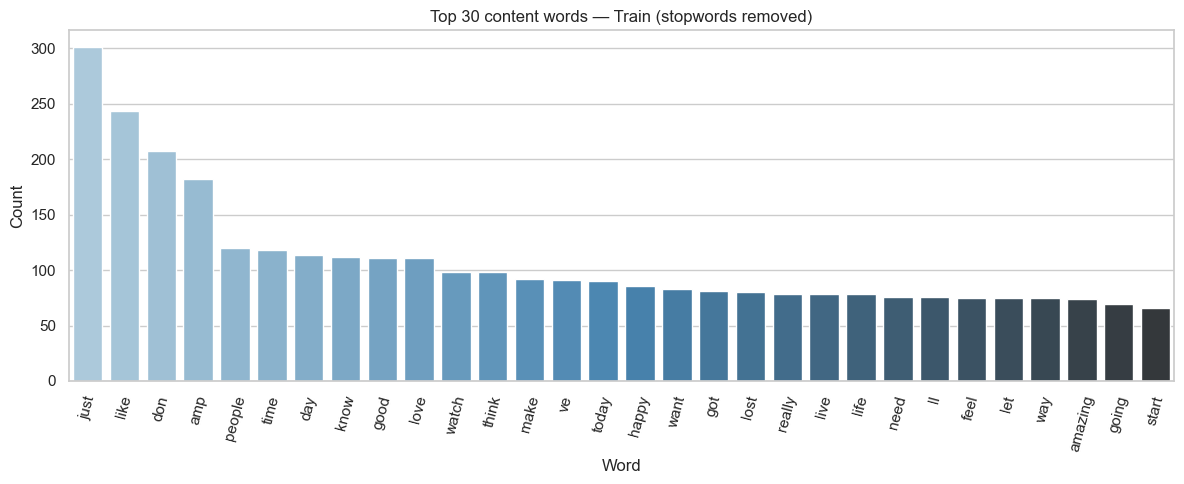

,word,count
0,just,301
1,like,243
2,don,207
3,amp,182
4,people,120
5,time,118
6,day,114
7,know,112
8,good,111
9,love,111


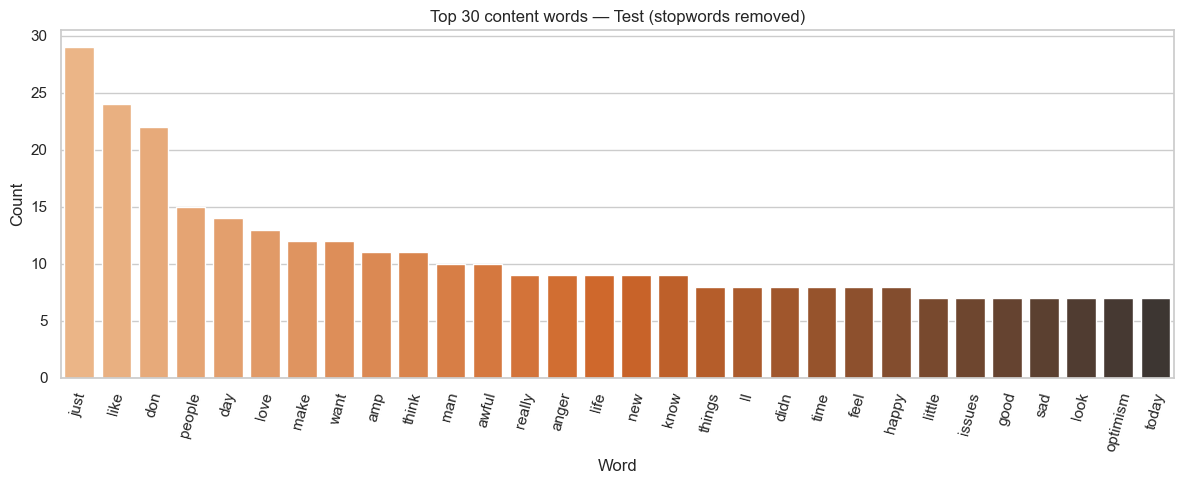

,word,count
0,just,29
1,like,24
2,don,22
3,people,15
4,day,14
5,love,13
6,make,12
7,want,12
8,amp,11
9,think,11


In [342]:
# Top-30 content-word frequency (stopwords removed to highlight meaningful tokens)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from IPython.display import display

# Explicit: text column created earlier is 'text'
text_col = 'text'

# Helper: compute top-n terms with English stopword filtering
def top_n_terms_filtered(df, text_col, n=30):
    # Remove common English stopwords so frequent content words appear
    vect = CountVectorizer(stop_words='english')
    texts = df[text_col].fillna("").astype(str)
    X = vect.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    if freqs.size == 0:
        return pd.DataFrame(columns=['word','count'])
    top_idx = np.argsort(freqs)[::-1][:min(n, freqs.size)]
    terms = vect.get_feature_names_out()[top_idx]
    counts = freqs[top_idx]
    return pd.DataFrame({'word': terms, 'count': counts})

TOP_N = 30
train_top = top_n_terms_filtered(train_df, text_col, TOP_N)
test_top  = top_n_terms_filtered(test_df,  text_col, TOP_N)

sns.set(style='whitegrid')

# Plot: Train (vertical bars, x-axis ordered by frequency descending)
plt.figure(figsize=(12,5))
order_train = train_top['word'].tolist()   # already in desc order
ax = sns.barplot(x='word', y='count', data=train_top, order=order_train, palette='Blues_d')
ax.set_title(f'Top {TOP_N} content words — Train (stopwords removed)')
ax.set_xlabel('Word')
ax.set_ylabel('Count')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()
display(train_top.reset_index(drop=True))

# Plot: Test (vertical bars, x-axis ordered by frequency descending)
plt.figure(figsize=(12,5))
order_test = test_top['word'].tolist()
ax2 = sns.barplot(x='word', y='count', data=test_top, order=order_test, palette='Oranges_d')
ax2.set_title(f'Top {TOP_N} content words — Test (stopwords removed)')
ax2.set_xlabel('Word')
ax2.set_ylabel('Count')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()
display(test_top.reset_index(drop=True))

---
### <a id='toc1_5_2_'></a>[**1.2 Save data**](#toc0_)

We will save our data in Pickle format. The pickle module implements binary protocols for serializing and de-serializing a Python object structure.   
  
Some advantages for using pickle structure:  
* Because it stores the attribute type, it's more convenient for cross-platform use.  
* When your data is huge, it could use less space to store also consume less loading time.   

In [343]:
# save to pickle file
train_df.to_pickle("./data/train_df.pkl") 
test_df.to_pickle("./data/test_df.pkl")

In [344]:
import pandas as pd

# load a pickle file
train_df = pd.read_pickle("./data/train_df.pkl")
test_df = pd.read_pickle("./data/test_df.pkl")

For more information: https://reurl.cc/0Dzqx

---
### <a id='toc1_5_3_'></a>[**1.3 Exploratory data analysis (EDA)**](#toc0_)

Again, before getting our hands dirty, we need to explore a little bit and understand the data we're dealing with.

In [345]:
# group to find distribution
train_df.groupby(['emotion']).count()['text']

emotion
anger       857
fear       1147
joy         823
sadness     786
Name: text, dtype: int64

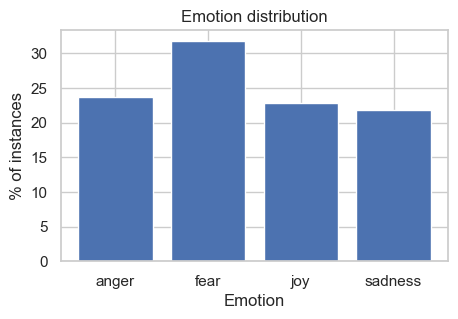

In [346]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# the histogram of the data
labels = train_df['emotion'].unique()
post_total = len(train_df)
df1 = train_df.groupby(['emotion']).count()['text']
df1 = df1.apply(lambda x: round(x*100/post_total,3))

#plot
fig, ax = plt.subplots(figsize=(5,3))
plt.bar(df1.index,df1.values)

#arrange
plt.ylabel('% of instances')
plt.xlabel('Emotion')
plt.title('Emotion distribution')
plt.grid(True)
plt.show()

---

## <a id='toc1_6_'></a>[**2. Feature engineering**](#toc0_)
### <a id='toc1_6_1_'></a>[Using Bag of Words](#toc0_)
Using scikit-learn ```CountVectorizer``` perform word frequency and use these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [347]:
from sklearn.feature_extraction.text import CountVectorizer

In [348]:
# build analyzers (bag-of-words)
BOW_vectorizer = CountVectorizer() 

In [349]:
# 1. Learn a vocabulary dictionary of all tokens in the raw documents.
BOW_vectorizer.fit(train_df['text'])

# 2. Transform documents to document-term matrix.
train_data_BOW_features = BOW_vectorizer.transform(train_df['text'])
test_data_BOW_features = BOW_vectorizer.transform(test_df['text'])

In [350]:
# check the result
train_data_BOW_features

<3613x10115 sparse matrix of type '<class 'numpy.int64'>'
	with 51467 stored elements in Compressed Sparse Row format>

In [351]:
type(train_data_BOW_features)

scipy.sparse._csr.csr_matrix

In [352]:
# add .toarray() to show
train_data_BOW_features.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [353]:
# check the dimension
train_data_BOW_features.shape

(3613, 10115)

In [354]:
# observe some feature names
feature_names = BOW_vectorizer.get_feature_names_out()
feature_names[1000:1110]

array(['beck', 'beckett', 'become', 'becoming', 'becouse', 'becz', 'bed',
       'beds', 'bedtime', 'bee', 'beef', 'been', 'beer', 'beetuppy',
       'before', 'began', 'begin', 'beginning', 'begins', 'begun',
       'behappy', 'behave', 'behavior', 'behaviour', 'behind', 'beiirkes',
       'being', 'beingbrilliant', 'beingedited', 'beings', 'believe',
       'believed', 'believeinblue18', 'believetour', 'belittling',
       'bellaissocute', 'bellawines', 'belly', 'belongings', 'ben',
       'benadryl', 'benching', 'bend', 'bender', 'beneath', 'benefit',
       'benefits', 'benevans', 'benghazi', 'bennett', 'benoakley',
       'berbaqueue', 'bernabéu', 'berniedole', 'berniesanders', 'berry',
       'bertgatti', 'bes', 'beside', 'besides', 'best', 'bestadvice',
       'bestdayever', 'bestinbusiness', 'bestrides', 'bestrong', 'bet',
       'betelgeuse', 'bethenny', 'bethpylieberman', 'better',
       'better2day', 'bettertogether', 'between', 'bey', 'beyond',
       'beyondajoke', 'beyon

The embedding is done. We can technically feed this into our model. However, depending on the embedding technique you use and your model, your accuracy might not be as high, because:

* curse of dimensionality  (we have 10,115 dimension now)
* some important features are ignored (for example, some models using emoticons yeld better performance than counterparts)

In [355]:
"😂" in feature_names

False

Let's try using another tokenizer below.

In [356]:
import nltk

# build analyzers (bag-of-words)
BOW_500 = CountVectorizer(max_features=500, tokenizer=nltk.word_tokenize) 

# apply analyzer to training data
BOW_500.fit(train_df['text'])

train_data_BOW_features_500 = BOW_500.transform(train_df['text'])

## check dimension
train_data_BOW_features_500.shape

(3613, 500)

In [357]:
train_data_BOW_features_500.toarray()

array([[0, 2, 0, ..., 0, 0, 0],
       [0, 2, 0, ..., 0, 0, 0],
       [0, 3, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 2, 0, ..., 0, 0, 0]])

In [358]:
# observe some feature names
feature_names_500 = BOW_500.get_feature_names_out()
feature_names_500[100:110]

array(['change', 'cheer', 'cheerful', 'cheerfully', 'cheering', 'cheery',
       'come', 'comes', 'could', 'country'], dtype=object)

In [359]:
"😂" in feature_names_500

True

---
##### <a id='toc1_6_1_1_1_'></a>[**>>> Exercise 2 (Take home):**](#toc0_)
Generate an embedding using the TF-IDF vectorizer instead of th BOW one with 1000 features and show the feature names for features [100:110].

In [360]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Build TF-IDF with 1000 features and fit on training texts
tfidf = TfidfVectorizer(max_features=1000)
texts = train_df['text'].fillna('').astype(str)
X_train_tfidf = tfidf.fit_transform(texts)

# Feature names and inspection for indices [100:110]
feature_names = tfidf.get_feature_names_out()
print("TF-IDF feature count:", len(feature_names))
print("Feature names [100:110]:")
for idx, fname in enumerate(feature_names[100:110], start=100):
    print(idx, fname)

# return slice for further inspection if needed
feature_names[100:110]

TF-IDF feature count: 1000
Feature names [100:110]:
100 bitter
101 black
102 blacks
103 blame
104 blessed
105 blood
106 bloody
107 blues
108 body
109 boiling


array(['bitter', 'black', 'blacks', 'blame', 'blessed', 'blood', 'bloody',
       'blues', 'body', 'boiling'], dtype=object)

---
## <a id='toc1_7_'></a>[**3. Model**](#toc0_)
### <a id='toc1_7_1_'></a>[**3.1 Decision Trees**](#toc0_)
Using scikit-learn ```DecisionTreeClassifier``` performs word frequency and uses these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [361]:
from sklearn.tree import DecisionTreeClassifier

# for a classificaiton problem, you need to provide both training & testing data
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## take a look at data dimension is a good habit  :)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

X_train.shape:  (3613, 500)
y_train.shape:  (3613,)
X_test.shape:  (347, 500)
y_test.shape:  (347,)


In [362]:
## build DecisionTree model
DT_model = DecisionTreeClassifier(random_state=1)

## training!
DT_model = DT_model.fit(X_train, y_train)

## predict!
y_train_pred = DT_model.predict(X_train)
y_test_pred = DT_model.predict(X_test)

## so we get the pred result
y_test_pred[:10]

array(['joy', 'fear', 'fear', 'fear', 'joy', 'anger', 'fear', 'fear',
       'sadness', 'sadness'], dtype=object)

---
## <a id='toc1_8_'></a>[**4. Results Evaluation**](#toc0_)

Now we will check the results of our model's performance

In [363]:
## accuracy
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_true=y_train, y_pred=y_train_pred)
acc_test = accuracy_score(y_true=y_test, y_pred=y_test_pred)

print('training accuracy: {}'.format(round(acc_train, 2)))
print('testing accuracy: {}'.format(round(acc_test, 2)))


training accuracy: 0.99
testing accuracy: 0.68


In [ ]:
## precision, recall, f1-score,
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=y_test_pred))

              precision    recall  f1-score   support

       anger       0.66      0.68      0.67        84
        fear       0.66      0.69      0.67       110
         joy       0.72      0.71      0.71        79
     sadness       0.70      0.64      0.67        74

    accuracy                           0.68       347
   macro avg       0.68      0.68      0.68       347
weighted avg       0.68      0.68      0.68       347



In [365]:
## check by confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true=y_test, y_pred=y_test_pred) 
print(cm)

[[57 18  6  3]
 [16 76  9  9]
 [ 6  9 56  8]
 [ 7 13  7 47]]


In [366]:
# Funciton for visualizing confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    """
    This function is modified from: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    classes.sort()
    tick_marks = np.arange(len(classes))    
    
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

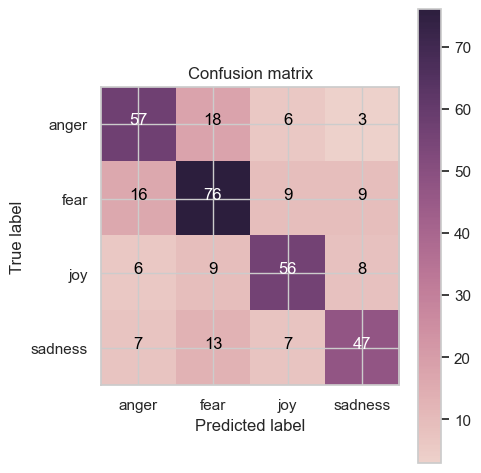

In [367]:
# plot your confusion matrix
my_tags = ['anger', 'fear', 'joy', 'sadness']
plot_confusion_matrix(cm, classes=my_tags, title='Confusion matrix')

---
##### <a id='toc1_8_1_1_1_'></a>[**>>> Exercise 3 (Take home):**](#toc0_)
Can you interpret the results above? What do they mean?

In [ ]:
# Interpretation
# The confusion matrix shows correct predictions on the diagonal (57, 76, 56, 47 for anger, fear, joy, sadness respectively) and the off-diagonal counts reveal the main confusions. 
# Per-class recall is roughly: anger 57/84 about 68%, fear 76/110 about 69%, joy 56/79 about 71%, and sadness 47/74 about 64%. The largest, systematic errors are mutual confusion between anger and fear (18 anger->fear and 16 fear->anger) and a tendency to mislabel sadness as fear (13 sadness->fear, about 18% of sadness examples). 
# In short: joy is the most cleanly recognized class in this matrix, sadness has the weakest recall, and the model often confuses emotionally-similar classes (anger vs. fear and sadness->fear). Probably also because Fear has more samples, so the model is biased towards predicting Fear which leads to more misclassifications into Fear.


---
##### <a id='toc1_8_1_1_2_'></a>[**>>> Exercise 4 (Take home):**](#toc0_)
Build a model using a ```Naive Bayes``` model and train it. What are the testing results? 

*Reference*: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

In [369]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Multinomial Naive Bayes on existing features
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predictions
y_train_pred = nb.predict(X_train)
y_test_pred = nb.predict(X_test)

# Results
print('training accuracy: {}'.format(round(accuracy_score(y_train, y_train_pred), 2)))
print('testing accuracy: {}'.format(round(accuracy_score(y_test, y_test_pred), 2)))
print('\nClassification report (test):')
print(classification_report(y_test, y_test_pred))
print('\nConfusion matrix (rows=true, cols=pred) [order: anger, fear, joy, sadness]:')
print(confusion_matrix(y_test, y_test_pred, labels=['anger','fear','joy','sadness']))

training accuracy: 0.79
testing accuracy: 0.7

Classification report (test):
              precision    recall  f1-score   support

       anger       0.63      0.65      0.64        84
        fear       0.73      0.77      0.75       110
         joy       0.78      0.71      0.74        79
     sadness       0.64      0.62      0.63        74

    accuracy                           0.70       347
   macro avg       0.70      0.69      0.69       347
weighted avg       0.70      0.70      0.70       347


Confusion matrix (rows=true, cols=pred) [order: anger, fear, joy, sadness]:
[[55 15  5  9]
 [ 9 85  5 11]
 [11  6 56  6]
 [12 10  6 46]]


---
##### <a id='toc1_8_1_1_3_'></a>[**>>> Exercise 5 (Take home):**](#toc0_)

How do the results from the Naive Bayes model and the Decision Tree model compare? How do you interpret these differences? Use the theoretical background covered in class to try and explain these differences.

In [ ]:
# Comparison of Decision Tree vs. Multinomial Naive Bayes on Emotion Classification

# Decision Tree(DT)
# Train acc: 0.99, Test acc: 0.68
# Test per-class (precision / recall / f1):
# anger 0.66 / 0.68 / 0.67
# fear 0.66 / 0.69 / 0.67
# joy 0.72 / 0.71 / 0.71
# sadness 0.70 / 0.64 / 0.67
# Confusion matrix (true rows -> pred cols):
# [[57,18,6,3], [16,76,9,9], [6,9,56,8], [7,13,7,47]]

# Multinomial Naive Bayes (MNB)
# Train acc: 0.79, Test acc: 0.70
# Test per-class (precision / recall / f1):
# anger 0.63 / 0.65 / 0.64
# fear 0.73 / 0.77 / 0.75
# joy 0.78 / 0.71 / 0.74
# sadness 0.64 / 0.62 / 0.63
# Confusion matrix (true rows -> pred cols):
# [[55,15,5,9], [9,85,5,11], [11,6,56,6], [12,10,6,46]]
# Key comparisons and interpretation
# Overall generalization

# Decision Tree: extremely high train acc (0.99) with much lower test acc (0.68) -> strong overfitting (high variance).
# MNB: lower train acc (0.79) and slightly higher test acc (0.70) -> better generalization (lower variance, more bias).
# Bottom line: MNB generalizes better on this dataset (test accuracy +0.02).

# Per-class behavior
# Fear and Joy improved under MNB (fear f1: 0.67 to 0.75; joy f1: 0.71 to 0.74).
# Anger and Sadness slightly worse on MNB (anger f1 0.67 to 0.64; sadness 0.67 to 0.63).
# This indicates MNB better captures the distributions for fear and joy (more stable aggregated evidence), while the DT had decision rules helping anger/sadness slightly in some ways.

# Confusion matrix patterns (what changed)
# Anger <-> Fear: DT had strong mutual confusion (anger->fear 18, fear→anger 16). MNB reduced fear→anger to 9 and anger -> fear to 15 —> asymmetric improvement, especially in fear->anger.
# Sadness <-> Fear / Anger: DT had sadness→fear 13 and sadness→anger 7; MNB shifted sadness→anger up (12) and sadness→fear down (10). So some errors moved to different off-diagonals.
# Joy is relatively stable (diagonal entries ~56). MNB increases some anger/joy and joy/anger swaps slightly but maintains strong recognition of joy.
# Interpretation: MNB smooths predictions across many features; it reduces some symmetric misclassifications (e.g., fear→anger), but can produce different mistakes (e.g., more sadness->anger), reflecting how aggregated log-probabilities differ from decision-tree splits.
# Theoretical reasons (connect to class theory)

# Decision Tree
# Low bias, high variance. Splitting on single tokens or token combinations can create very specific rules that fit training noise.
# Able to exploit highly predictive but rare tokens —> good for training accuracy, brittle on unseen test tokens.

# Multinomial Naive Bayes
# Higher bias due to conditional independence assumption, but low variance —> aggregates (summed) evidence across many words.
# Well-suited for high-dimensional sparse text; smoothing (alpha) mitigates zero-probability issues.
# Less likely to overfit to rare token combinations, so it generalizes better on held-out data here.

# Feature effect: DT is sensitive to individual discriminative features (single words) while NB weights all features additively.c

---

## <a id='toc1_9_'></a>[**5. Other things you can try**](#toc0_)

Thus, there are several things you can try that will affect your results. In order to yield better results, you can experiment by: 
- Trying different features (Feature engineering)e.g Word2Vec, PCA, LDA, FastText, Clustering
- Trying different models
- Analyzing your results and interpret them to improve your feature engineering/model building process
- Iterate through the steps above until finding a satisfying result

Remember that you should also consider the task at hand and the model you'll feed the data to. 

---
## <a id='toc1_10_'></a>[**6. Deep Learning**](#toc0_)

We use [Keras](https://keras.io/) to be our deep learning framework, and follow the [Model (functional API)](https://keras.io/models/model/) to build a Deep Neural Network (DNN) model. Keras runs with Tensorflow in the backend. It's a nice abstraction to start working with NN models. 

Because Deep Learning is a 1-semester course, we can't talk about each detail about it in the lab session. Here, we only provide a simple template about how to build & run a DL model successfully. You can follow this template to design your model.

We will begin by building a fully connected network, which looks like this:

![pic1.png](./pics/pic1.png)

(source: https://github.com/drewnoff/spark-notebook-ml-labs/tree/master/labs/DLFramework)


---
### <a id='toc1_10_1_'></a>[**6.1 Prepare data (X, y)**](#toc0_)

In [371]:
import keras

# standardize name (X, y) 
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## check dimension is a good habbit 
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

X_train.shape:  (3613, 500)
y_train.shape:  (3613,)
X_test.shape:  (347, 500)
y_test.shape:  (347,)


In [372]:
import keras

In [373]:
BOW_500.transform(test_df['text'])

<347x500 sparse matrix of type '<class 'numpy.int64'>'
	with 4103 stored elements in Compressed Sparse Row format>

---
### <a id='toc1_10_2_'></a>[**6.2 Deal with categorical label (y)**](#toc0_)

Rather than put your label `train_df['emotion']` directly into a model, we have to process these categorical (or say nominal) label by ourselves. 

Here, we use the basic method [one-hot encoding](https://en.wikipedia.org/wiki/One-hot) to transform our categorical  labels to numerical ones.


In [374]:
# deal with label (string -> one-hot)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(y_train)

print('check label: ', label_encoder.classes_)
print('\n## Before convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)

def label_encode(le, labels):
    enc = le.transform(labels)
    return keras.utils.to_categorical(enc)

def label_decode(le, one_hot_label):
    dec = np.argmax(one_hot_label, axis=1)
    return le.inverse_transform(dec)

check label:  ['anger' 'fear' 'joy' 'sadness']

## Before convert
y_train[0:4]:
 1298       fear
3259    sadness
1032       fear
1703       fear
Name: emotion, dtype: object

y_train.shape:  (3613,)
y_test.shape:  (347,)


In [375]:
y_train = label_encode(label_encoder, y_train)
y_test = label_encode(label_encoder, y_test)

print('\n\n## After convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)




## After convert
y_train[0:4]:
 [[0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]

y_train.shape:  (3613, 4)
y_test.shape:  (347, 4)


---
### <a id='toc1_10_3_'></a>[**6.3 Build model**](#toc0_)

In [376]:
# I/O check
input_shape = X_train.shape[1]
print('input_shape: ', input_shape)

output_shape = len(label_encoder.classes_)
print('output_shape: ', output_shape)

input_shape:  500
output_shape:  4


![pic2.png](./pics/pic2.png)

In [377]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.layers import ReLU, Softmax

# input layer
model_input = Input(shape=(input_shape, ))  # 500
X = model_input

# 1st hidden layer
X_W1 = Dense(units=64)(X)  # 64
H1 = ReLU()(X_W1)

# 2nd hidden layer
H1_W2 = Dense(units=64)(H1)  # 64
H2 = ReLU()(H1_W2)

# output layer
H2_W3 = Dense(units=output_shape)(H2)  # 4
H3 = Softmax()(H2_W3)

model_output = H3

# create model
model = Model(inputs=[model_input], outputs=[model_output])

# loss function & optimizer
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# show model construction
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_5 (Softmax)             │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,484 (142.52 KB)

 Trainable params: 36,484 (142.52 KB)

 Non-trainable params: 0 (0.00 B)

---
### <a id='toc1_10_4_'></a>[**6.4 Train**](#toc0_)

In [378]:
from keras.callbacks import CSVLogger

csv_logger = CSVLogger('logs/training_log.csv')

# training setting
epochs = 25
batch_size = 32

# training!
history = model.fit(X_train, y_train, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    callbacks=[csv_logger],
                    validation_data = (X_test, y_test))
print('training finish')

Epoch 1/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3557 - loss: 1.3371 - val_accuracy: 0.4524 - val_loss: 1.2844
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6468 - loss: 0.9975 - val_accuracy: 0.6657 - val_loss: 0.8959
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7977 - loss: 0.5727 - val_accuracy: 0.7176 - val_loss: 0.7670
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8450 - loss: 0.4166 - val_accuracy: 0.7147 - val_loss: 0.7416
Epoch 5/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8807 - loss: 0.3311 - val_accuracy: 0.7320 - val_loss: 0.7808
Epoch 6/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8990 - loss: 0.2821 - val_accuracy: 0.7003 - val_loss: 0.8212
Epoch 7/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9233 - loss: 0.2325 - val_accuracy: 0.7003 - val_loss: 0.8892
Epoch 8/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9394 - loss: 0.1948 - val_accuracy: 0.

---
### <a id='toc1_10_5_'></a>[**6.5 Predict on testing data**](#toc0_)

In [379]:
## predict
pred_result = model.predict(X_test, batch_size=128)
pred_result[:5]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[2.1637841e-01, 9.0858608e-02, 5.7109630e-01, 1.2166664e-01],
       [1.8539615e-05, 9.9958658e-01, 1.5047636e-05, 3.7973854e-04],
       [1.9502036e-09, 1.0000000e+00, 1.3490240e-11, 1.7099635e-08],
       [3.3397198e-05, 9.9831980e-01, 3.6134752e-05, 1.6105480e-03],
       [1.3944940e-06, 4.7852564e-07, 9.9999797e-01, 1.0370369e-07]],
      dtype=float32)

In [380]:
pred_result = label_decode(label_encoder, pred_result)
pred_result[:5]

array(['joy', 'fear', 'fear', 'fear', 'joy'], dtype=object)

In [381]:
from sklearn.metrics import accuracy_score

print('testing accuracy: {}'.format(round(accuracy_score(label_decode(label_encoder, y_test), pred_result), 2)))

testing accuracy: 0.66


In [382]:
#Let's take a look at the training log
training_log = pd.DataFrame()
training_log = pd.read_csv("logs/training_log.csv")
training_log

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.355660,1.337097,0.452450,1.284374
1,1,0.646831,0.997506,0.665706,0.895886
2,2,0.797675,0.572726,0.717579,0.767035
3,3,0.845004,0.416585,0.714697,0.741589
4,4,0.880709,0.331065,0.731988,0.780848
5,5,0.898976,0.282148,0.700288,0.821159
6,6,0.923332,0.232521,0.700288,0.889202
7,7,0.939386,0.194828,0.708934,0.939145
8,8,0.946859,0.166029,0.708934,0.966286
9,9,0.953501,0.145245,0.706052,1.049793


---
##### <a id='toc1_10_5_1_1_'></a>[**>>> Exercise 6 (Take home):**](#toc0_)

Plot the Training and Validation Accuracy and Loss (different plots), just like the images below.(Note: the pictures below are an example from a different model). How to interpret the graphs you got? How are they related to the concept of overfitting/underfitting covered in class?

![pic3.png](./pics/pic3.png)  ![pic4.png](./pics/pic4.png)


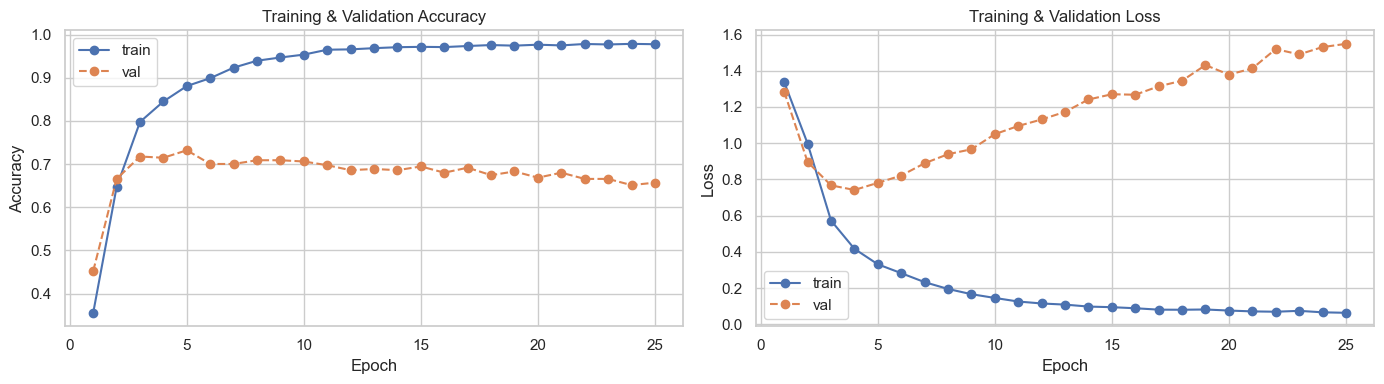

Final epoch (train / val when available):
  Accuracy: train=0.9776, val=0.6571
  Loss:     train=0.0632, val=1.5484


In [ ]:
# Exercise 6 — Plot Training & Validation Accuracy / Loss Over Epochs
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Use seaborn theme (seaborn is used elsewhere in this notebook)
sns.set_theme(style='whitegrid')

# Get training history as a DataFrame: prefer Keras `history`, fall back to CSV
if 'history' in globals() and hasattr(history, 'history'):
    df = pd.DataFrame(history.history)
else:
    # CSVLogger wrote this file during training
    df = pd.read_csv("logs/training_log.csv")

# Normalize and find column names (simple lower-case lookup)
cols = list(df.columns)
lower = [c.lower() for c in cols]

def find_col(key):
    for i, lc in enumerate(lower):
        if key in lc:
            return cols[i]
    return None

acc_col = find_col('accuracy')       # picks 'accuracy' (not 'val_...')
val_acc_col = find_col('val_accuracy') or find_col('val_acc')
loss_col = find_col('loss')          # picks 'loss' (not 'val_...')
val_loss_col = find_col('val_loss')

# Prepare epoch axis
epochs = range(1, len(df) + 1)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
if acc_col:
    ax1.plot(epochs, df[acc_col], marker='o', label='train')
if val_acc_col:
    ax1.plot(epochs, df[val_acc_col], '--', marker='o', label='val')
ax1.set_title('Training & Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='best')

# Loss
if loss_col:
    ax2.plot(epochs, df[loss_col], marker='o', label='train')
if val_loss_col:
    ax2.plot(epochs, df[val_loss_col], '--', marker='o', label='val')
ax2.set_title('Training & Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

# Final epoch summary
print("Final epoch (train / val when available):")
if acc_col:
    s = f"  Accuracy: train={df[acc_col].iloc[-1]:.4f}"
    if val_acc_col:
        s += f", val={df[val_acc_col].iloc[-1]:.4f}"
    print(s)
if loss_col:
    s = f"  Loss:     train={df[loss_col].iloc[-1]:.4f}"
    if val_loss_col:
        s += f", val={df[val_loss_col].iloc[-1]:.4f}"
    print(s)

# Interpretation of Training & Validation Curves
# What the graphs show (plain observation)
# Training accuracy: climbs quickly and reaches ~0.98-0.995 by ~10-25 epochs (almost perfect on training set).
# Validation accuracy: jumps early to  approximately 0.65-0.72, then slowly drifts around 0.65-0.70 with small fluctuations —> it never approaches the training accuracy.
# Training loss: falls steadily from ~1.3 to near 0.05 across epochs.
# Validation loss: declines a little early, reaches a low around epoch ~3-6, then steadily increases from there up to ~1.4 by epoch 25.
# Key numeric/visual clue: large gap between very low training loss / very high training accuracy and much higher validation loss / lower validation accuracy.

# How this maps to overfitting / underfitting (class concepts)
# Underfitting (high bias) would show both low training and low validation performance (e.g., low accuracy on both). That's not happening here: training performance is excellent.
# Overfitting (high variance) is exactly what we see:
# Training loss -> very low and training accuracy → very high (model fits training set very well).
# Validation loss increases after a few epochs and validation accuracy plateaus/falls —> model performance on unseen data is worse and degrades as training continues.
# The rising validation loss while training loss keeps dropping is a classic sign of overfitting: the model starts memorizing training examples and tuning to noise/features that don't generalize.
# Bias-variance framing: low bias (training error low), high variance (generalization gap large).
# Practical takeaway: the model's best generalization appears early (around the epoch where validation loss is lowest / validation accuracy peaks —> visually around epoch ~4-6). After that, continuing to train hurts generalization.
# 

---

### <a id='toc1_10_6_'></a>[Note](#toc0_)

If you don't have a GPU (level is higher than GTX 1060) or you are not good at setting lots of things about computer, we recommend you to use the [kaggle kernel](https://www.kaggle.com/kernels) to do deep learning model training. They have already installed all the librarys and provided free GPU for you to use.

Note however that you will only be able to run a kernel for 6 hours. After 6 hours of inactivity, your Kaggle kernel will shut down (meaning if your model takes more than 6 hours to train, you can't train it at once).


### <a id='toc1_10_7_'></a>[More Information for your reference](#toc0_)

* Keras document: https://keras.io/
* Keras GitHub example: https://github.com/keras-team/keras/tree/master/examples
* CS229: Machine Learning: http://cs229.stanford.edu/syllabus.html
* Deep Learning cheatsheet: https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-deep-learning
* If you want to try TensorFlow or PyTorch: https://pytorch.org/tutorials/
https://www.tensorflow.org/tutorials/quickstart/beginner

---
## <a id='toc1_11_'></a>[**7. Word2Vector**](#toc0_)

We will introduce how to use `gensim` to train your word2vec model and how to load a pre-trained model.

https://radimrehurek.com/gensim/index.html

---
### <a id='toc1_11_1_'></a>[**7.1 Prepare training corpus**](#toc0_)

In [403]:
## check library
import gensim

## ignore warnings
import warnings
warnings.filterwarnings('ignore')

# # if you want to see the training messages, you can use it
# import logging
# logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

## the input type
train_df['text_tokenized'] = train_df['text'].apply(lambda x: nltk.word_tokenize(x))
train_df[['id', 'text', 'text_tokenized']].head()

,id,text,text_tokenized
1298,20441,"When you wake up, scroll through social media,...","[When, you, wake, up, ,, scroll, through, soci..."
3259,40432,@SkyNews err I wasnt gloomy. 17.2 mio people ...,"[@, SkyNews, err, I, wasnt, gloomy, ., 17.2, m..."
1032,20175,Avoiding #fears only makes them scarier. Whate...,"[Avoiding, #, fears, only, makes, them, scarie..."
1703,20846,"thank you for your concern, computer, but my l...","[thank, you, for, your, concern, ,, computer, ..."
1467,20610,@ScottiePass shock horror handicap dodger is a...,"[@, ScottiePass, shock, horror, handicap, dodg..."


In [404]:
## create the training corpus
training_corpus = train_df['text_tokenized'].values
training_corpus[:3]

array([list(['When', 'you', 'wake', 'up', ',', 'scroll', 'through', 'social', 'media', ',', 'and', 'another', 'father', 'was', 'taken', 'from', 'his', 'child', '#', 'everyday', '#', 'KeithLamontScott']),
       list(['@', 'SkyNews', 'err', 'I', 'wasnt', 'gloomy', '.', '17.2', 'mio', 'people', 'were', 'not', 'gloomy', 'only', '#', 'remain', 'were', '#', 'Brexit']),
       list(['Avoiding', '#', 'fears', 'only', 'makes', 'them', 'scarier', '.', 'Whatever', 'your', '#', 'fear', ',', 'if', 'you', 'face', 'it', ',', 'it', 'should', 'start', 'to', 'fade', '.', '#', 'courage'])],
      dtype=object)

---
### <a id='toc1_11_2_'></a>[**7.2 Training our model**](#toc0_)

You can try to train your own model. More details: https://radimrehurek.com/gensim/models/word2vec.html

In [407]:
from gensim.models import Word2Vec

## setting
vector_dim = 100
window_size = 5
min_count = 1
training_epochs = 20

## model
word2vec_model = Word2Vec(sentences=training_corpus, 
                          vector_size=vector_dim, window=window_size, 
                          min_count=min_count, epochs=training_epochs)

![Imgur](https://i.imgur.com/Fca3MCs.png)

---
### <a id='toc1_11_3_'></a>[**7.3 Generating word vector (embeddings)**](#toc0_)

In [408]:
# get the corresponding vector of a word
word_vec = word2vec_model.wv['happy']
word_vec

array([ 4.6316186e-01,  6.9753414e-01, -8.7113045e-02, -3.3485178e-02,
        9.7567495e-04, -1.5222915e+00,  4.8621702e-01,  1.5891516e+00,
       -7.8798819e-01, -1.1134146e+00, -5.1737857e-01, -5.6485409e-01,
       -2.7628258e-01,  7.4475276e-01, -2.8262079e-01, -4.2868510e-01,
        2.2424768e-01, -7.4466681e-01,  4.0521291e-01, -1.0674652e+00,
        6.6963685e-01,  5.8155859e-01,  6.6295946e-01,  2.4265300e-01,
        2.1967778e-01, -2.6418647e-01, -4.6797878e-01,  5.2701408e-01,
       -4.9438405e-01,  4.3085948e-02,  5.8518618e-01, -2.4155323e-01,
        5.6171632e-01, -9.7025675e-01, -1.5609255e-01,  3.6832678e-01,
        4.1437951e-01,  1.7386394e-02,  4.2934489e-02, -7.8536850e-01,
       -1.7036092e-02,  1.0184103e-01, -5.2918893e-01,  3.0952239e-01,
        4.6516269e-01, -2.0065455e-01, -1.1931447e+00,  1.5656511e-01,
        1.8789706e-01,  4.2537898e-01, -4.3596886e-02, -2.1758914e-01,
       -3.3891771e-02, -7.0187432e-01, -1.8613651e-01, -3.3214709e-01,
      

In [409]:
# Get the most similar words
word = 'happy'
topn = 10
word2vec_model.wv.most_similar(word, topn=topn)

[('bday', 0.949280321598053),
 ('birthday', 0.9327796101570129),
 ("'be", 0.9230086207389832),
 ('Be', 0.9189945459365845),
 ('O', 0.9163661003112793),
 ('Kik', 0.9160856008529663),
 ('Read', 0.9143848419189453),
 ('blessed', 0.9111465811729431),
 ('RaisingTheBoss', 0.9091576337814331),
 ('help', 0.9061722755432129)]

---
### <a id='toc1_11_4_'></a>[**7.4 Using a pre-trained w2v model**](#toc0_)

Instead of training your own model ,you can use a model that has already been trained. Here, we see 2 ways of doing that:


#### <a id='toc1_11_4_1_'></a>[(1) Download model by yourself](#toc0_)

Download from this link: [Kaggle | Google News Vectors](https://www.kaggle.com/datasets/didiersalazar/google-news-vectors)

Copy the data `GoogleNews-vectors-negative300.bin` into the following folder directory: `GoogleNews/`

source: [GoogleNews-vectors-negative300](https://code.google.com/archive/p/word2vec/)

more details: https://radimrehurek.com/gensim/models/keyedvectors.html

In [410]:
from gensim.models import KeyedVectors
# IMPORTANT: Please make sure that you have correctly downloaded the file and put it in the correct directory
## Note: this model is huge, this will take some time ...
model_path = "./GoogleNews/GoogleNews-vectors-negative300.bin"
w2v_google_model = KeyedVectors.load_word2vec_format(model_path, binary=True)
print('load ok')

w2v_google_model.most_similar('happy', topn=10)

load ok


[('glad', 0.7408890724182129),
 ('pleased', 0.6632170677185059),
 ('ecstatic', 0.6626912355422974),
 ('overjoyed', 0.6599286794662476),
 ('thrilled', 0.6514049172401428),
 ('satisfied', 0.6437949538230896),
 ('proud', 0.636042058467865),
 ('delighted', 0.627237856388092),
 ('disappointed', 0.6269949674606323),
 ('excited', 0.6247665286064148)]

#### <a id='toc1_11_4_2_'></a>[(2) Using gensim api](#toc0_)

Other pretrained models are available here: https://github.com/RaRe-Technologies/gensim-data

In [411]:
import gensim.downloader as api

## If you see `SSL: CERTIFICATE_VERIFY_FAILED` error, use this:
import ssl
import urllib.request
ssl._create_default_https_context = ssl._create_unverified_context

glove_twitter_25_model = api.load("glove-twitter-25")
print('load ok')

glove_twitter_25_model.most_similar('happy', topn=10)

load ok


[('birthday', 0.9577818512916565),
 ('thank', 0.937666654586792),
 ('welcome', 0.9336148500442505),
 ('love', 0.9176183342933655),
 ('miss', 0.9164500832557678),
 ('hello', 0.9158350825309753),
 ('thanks', 0.9150084853172302),
 ('merry', 0.9053248763084412),
 ('bless', 0.902732253074646),
 ('wish', 0.9013165235519409)]

---
### <a id='toc1_11_5_'></a>[**7.5 king + woman - man = ?**](#toc0_)

Let's run one of the most famous examples for Word2Vec and compute the similarity between these 3 words:

In [391]:
w2v_google_model.most_similar(positive=['king', 'woman'], negative=['man'])

[('queen', 0.7118192911148071),
 ('monarch', 0.6189674735069275),
 ('princess', 0.5902431011199951),
 ('crown_prince', 0.5499460697174072),
 ('prince', 0.5377321243286133),
 ('kings', 0.5236844420433044),
 ('Queen_Consort', 0.5235945582389832),
 ('queens', 0.5181134343147278),
 ('sultan', 0.5098593235015869),
 ('monarchy', 0.5087411403656006)]

---
##### <a id='toc1_11_5_1_1_'></a>[**>>> Exercise 7 (Take home):**](#toc0_)

Now, we have the word vectors, but our input data is a sequence of words (or say sentence). 
How can we utilize these "word" vectors to represent the sentence data and train our model?


In [ ]:
# Pooling+classifier
import nltk
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# tokenizer that handles NaN and non-string inputs
def safe_tokenize(text):
    if not isinstance(text, str):
        text = "" if pd.isna(text) else str(text)
    return nltk.word_tokenize(text)

# Create/ensure tokenized columns (overwrite to guarantee consistent tokenization)
train_df['text_tokenized'] = train_df['text'].fillna("").astype(str).apply(safe_tokenize)
test_df['text_tokenized']  = test_df['text'].fillna("").astype(str).apply(safe_tokenize)

print("Sample tokenization (train / test):")
print(train_df['text_tokenized'].iloc[0])
print(test_df['text_tokenized'].iloc[0])

# Rebuild TF-IDF-weighted pooled vectors and train classifier
use_tfidf_weights = True  # set False to use simple mean pooling
vector_size = word2vec_model.vector_size  # assumes word2vec_model already in memory

if use_tfidf_weights:
    # Fit TF-IDF on token lists (token lists are provided directly)
    tfidf = TfidfVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x, lowercase=False)
    train_tokens = train_df['text_tokenized'].tolist()
    tfidf.fit(train_tokens)

    def sentence_vector_tfidf(tokens):
        vecs = []
        weights = []
        for w in tokens:
            if w in word2vec_model.wv.key_to_index and w in tfidf.vocabulary_:
                w_idx = tfidf.vocabulary_[w]
                idf = tfidf.idf_[w_idx]
                vecs.append(word2vec_model.wv[w])
                weights.append(idf)
        if len(vecs) == 0:
            return np.zeros(vector_size, dtype=float)
        weights = np.array(weights)
        weights = weights / np.sum(weights)
        return np.sum(np.vstack(vecs) * weights[:, None], axis=0)

    X_train_vec = np.vstack([sentence_vector_tfidf(t) for t in train_df['text_tokenized']])
    X_test_vec  = np.vstack([sentence_vector_tfidf(t) for t in test_df['text_tokenized']])
else:
    def sentence_vector_avg(tokens, model, vector_size):
        vecs = [model.wv[word] for word in tokens if word in model.wv.key_to_index]
        if len(vecs) == 0:
            return np.zeros(vector_size, dtype=float)
        return np.mean(vecs, axis=0)

    X_train_vec = np.vstack([sentence_vector_avg(t, word2vec_model, vector_size) for t in train_df['text_tokenized']])
    X_test_vec  = np.vstack([sentence_vector_avg(t, word2vec_model, vector_size) for t in test_df['text_tokenized']])

# Labels (raw strings)
y_train_raw = train_df['emotion'].values
y_test_raw  = test_df['emotion'].values

# Train classifier and evaluate
clf = LogisticRegression(max_iter=1000, multi_class='multinomial')
clf.fit(X_train_vec, y_train_raw)
y_pred = clf.predict(X_test_vec)

print("Test accuracy after tokenization fix:", round(accuracy_score(y_test_raw, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test_raw, y_pred))

# TF‑IDF‑weighted pooled embeddings + fast classifier (used above)
# What: Build sentence vectors by taking a TF‑IDF weighted average of pretrained word vectors (we used gensim-loaded pretrained vectors — e.g., glove_twitter_25 and GoogleNews-vectors-negative300 as KeyedVectors), then train a multinomial LogisticRegression on those sentence embeddings.
# WHY USE IT: Using gensim KeyedVectors makes this pipeline very simple — you can look up each token’s vector directly and compute a weighted mean with TF‑IDF weights. It’s extremely fast to train and evaluate, robust on small datasets, and provides a reliable baseline with minimal engineering.
# TRADEOFFS: Loses word order and some compositional nuance. Dimensionality matters (25‑d GloVe is compact and fast; 300‑d GoogleNews gives richer representations but costs more memory/compute).

# Sequence model: Embedding + LSTM
# What: Tokenize text, map tokens to an embedding matrix (either randomly initialized or initialized from pretrained vectors aligned to your tokenizer), feed the token sequences into an LSTM (or bi‑LSTM), then a final softmax for classification.
# Why use it: Preserves word order and captures sequential/contextual patterns that pooling misses — often improves accuracy on harder tasks.
# Integration requirements & risks: Requires careful tokenizer <-> embedding alignment (vocabulary mapping, OOV handling), building an embedding matrix that matches your tokenizer indices (or using gensim vectors to initialize the Keras Embedding weights), and decisions on padding/truncation and sequence length. This pipeline also needs more compute and hyperparameter tuning (dropout, learning rate, regularization). Those integration pieces weren’t fully available for this lab, so we prioritized the robust pooling baseline.

Sample tokenization (train / test):
['When', 'you', 'wake', 'up', ',', 'scroll', 'through', 'social', 'media', ',', 'and', 'another', 'father', 'was', 'taken', 'from', 'his', 'child', '#', 'everyday', '#', 'KeithLamontScott']
['I', 'hate', 'it', 'when', 'im', 'singing', 'and', 'some', 'idiot', 'thinks', 'they', 'can', 'just', 'join', 'in', 'with', 'me', 'like', '...', 'this', 'is', 'not', 'fcking', 'glee', '#', 'MeanRikonaBot']
Test accuracy after tokenization fix: 0.3487

Classification report:
              precision    recall  f1-score   support

       anger       0.33      0.15      0.21        84
        fear       0.37      0.76      0.50       110
         joy       0.32      0.25      0.28        79
     sadness       0.24      0.05      0.09        74

    accuracy                           0.35       347
   macro avg       0.31      0.31      0.27       347
weighted avg       0.32      0.35      0.29       347



---
## <a id='toc1_12_'></a>[**8. Clustering: k-means**](#toc0_)

Here we introduce how to use `sklearn` to do the basic **unsupervised learning** approach, k-means.    

more details: http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


#### <a id='toc1_12_1_1_'></a>[Basic concept](#toc0_)

![pic5.png](./pics/pic5.png)

(img source: https://towardsdatascience.com/k-means-clustering-identifying-f-r-i-e-n-d-s-in-the-world-of-strangers-695537505d)

In [393]:
# clustering target
target_list = ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']
print('target words: ', target_list)

# convert to word vector
X = [word2vec_model.wv[word] for word in target_list]

target words:  ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']


In [394]:
from sklearn.cluster import KMeans

# we have to decide how many cluster (k) we want
k = 2

# k-means model
kmeans_model = KMeans(n_clusters=k)
kmeans_model.fit(X)

# cluster result
cluster_result = kmeans_model.labels_

# show
for i in range(len(target_list)):
    print('word: {} \t cluster: {}'.format(target_list[i], cluster_result[i]))

word: happy 	 cluster: 0
word: fear 	 cluster: 1
word: angry 	 cluster: 0
word: car 	 cluster: 0
word: teacher 	 cluster: 0
word: computer 	 cluster: 0


![pic6.png](./pics/pic6.png)

In [395]:
#check cluster membership
word = 'student'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([0], dtype=int32)

In [396]:
#check cluster membership
word = 'sad'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([1], dtype=int32)

---
## <a id='toc1_13_'></a>[**9. High-dimension Visualization: t-SNE and UMAP**](#toc0_)

No matter if you use the Bag-of-words, TF-IDF, or Word2Vec, it's very hard to see the embedding result, because the dimension is larger than 3.  

In Lab 1, we already talked about PCA, t-SNE and UMAP. We can use PCA to reduce the dimension of our data, then visualize it. However, if you dig deeper into the result, you'd find it is insufficient.

Our aim will be to create a visualization similar to the one below with t-SNE:

![pic7.png](./pics/pic7.png)

source: https://www.fabian-keller.de/research/high-dimensional-data-visualization 

And also like this for UMAP:

![pic9.png](./pics/pic9.png)

source: https://umap-learn.readthedocs.io/en/latest/auto_examples/plot_mnist_example.html

t-SNE and UMAP reference:  
http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html 
https://umap-learn.readthedocs.io/en/latest/

---
### <a id='toc1_13_1_'></a>[**9.1 Prepare visualizing target**](#toc0_)

Let's prepare data lists like:
- happy words
- angry words
- data words
- mining words

In [397]:
word_list = ['happy', 'angry', 'data', 'mining']

topn = 5
happy_words = ['happy'] + [word_ for word_, sim_ in w2v_google_model.most_similar('happy', topn=topn)]
angry_words = ['angry'] + [word_ for word_, sim_ in w2v_google_model.most_similar('angry', topn=topn)]        
data_words = ['data'] + [word_ for word_, sim_ in w2v_google_model.most_similar('data', topn=topn)]        
mining_words = ['mining'] + [word_ for word_, sim_ in w2v_google_model.most_similar('mining', topn=topn)]        

print('happy_words: ', happy_words)
print('angry_words: ', angry_words)
print('data_words: ', data_words)
print('mining_words: ', mining_words)

target_words = happy_words + angry_words + data_words + mining_words
print('\ntarget words: ')
print(target_words)

print('\ncolor list:')
cn = topn + 1
color = ['b'] * cn + ['g'] * cn + ['r'] * cn + ['y'] * cn
print(color)

happy_words:  ['happy', 'glad', 'pleased', 'ecstatic', 'overjoyed', 'thrilled']
angry_words:  ['angry', 'irate', 'enraged', 'indignant', 'incensed', 'annoyed']
data_words:  ['data', 'Data', 'datasets', 'dataset', 'databases', 'statistics']
mining_words:  ['mining', 'Mining', 'mines', 'coal_mining', 'mine', 'miner']

target words: 
['happy', 'glad', 'pleased', 'ecstatic', 'overjoyed', 'thrilled', 'angry', 'irate', 'enraged', 'indignant', 'incensed', 'annoyed', 'data', 'Data', 'datasets', 'dataset', 'databases', 'statistics', 'mining', 'Mining', 'mines', 'coal_mining', 'mine', 'miner']

color list:
['b', 'b', 'b', 'b', 'b', 'b', 'g', 'g', 'g', 'g', 'g', 'g', 'r', 'r', 'r', 'r', 'r', 'r', 'y', 'y', 'y', 'y', 'y', 'y']


---
### <a id='toc1_13_2_'></a>[**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc0_)

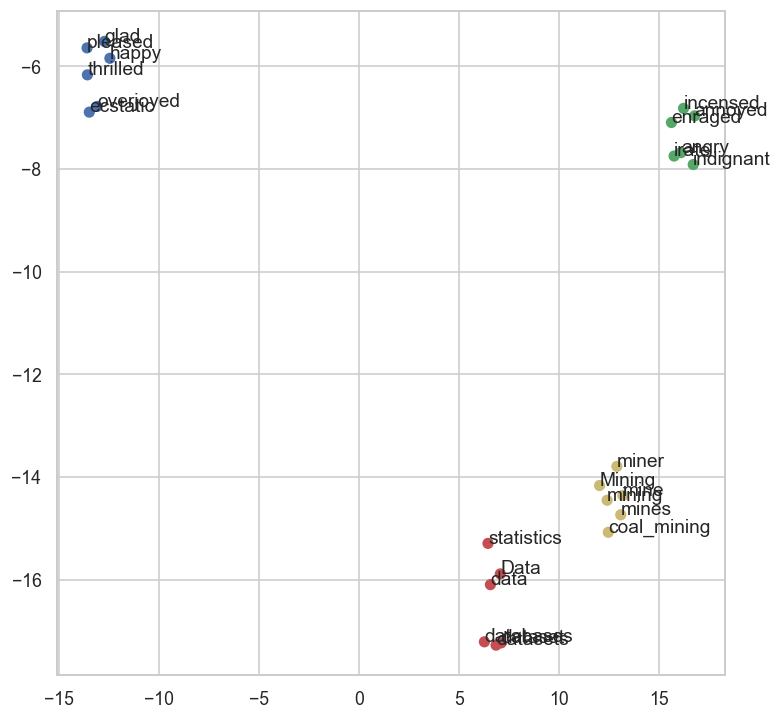

In [398]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## t-SNE model
tsne = TSNE(n_components=2, metric='cosine', random_state=28)

## training
X_tsne = tsne.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_tsne[:target_size, 0], X_tsne[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_tsne[:target_size, 0], X_tsne[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()

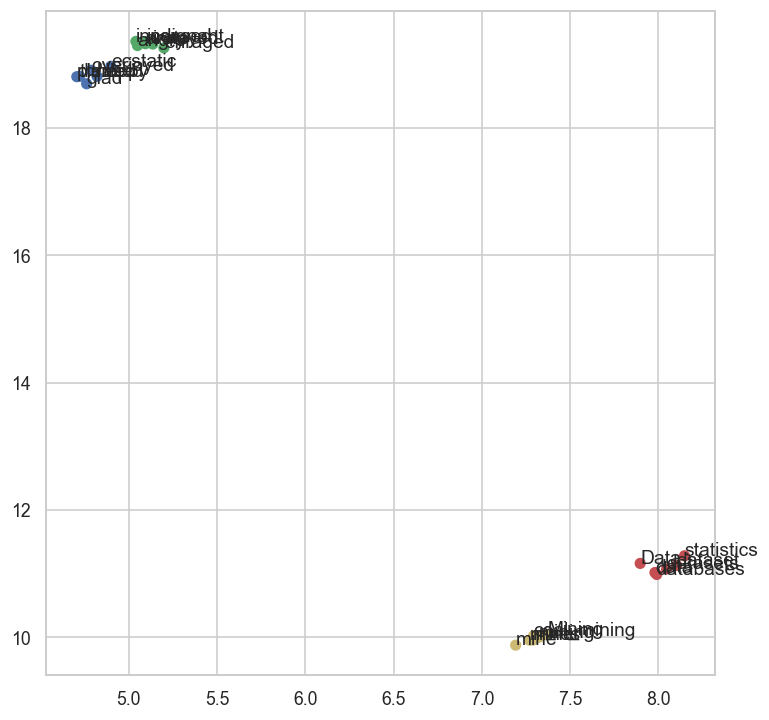

In [399]:
import matplotlib.pyplot as plt
import umap.umap_ as umap

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## UMAP model
umap_model = umap.UMAP(n_components=2, metric='cosine', random_state=28)

## training
X_umap = umap_model.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_umap[:target_size, 0], X_umap[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_umap[:target_size, 0], X_umap[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()


---
##### <a id='toc1_13_2_1_1_'></a>[**>>> Exercise 8 (Take home):**](#toc0_)

Generate a t-SNE and UMAP visualization to show the 15 words most related to the words "angry", "happy", "sad", "fear" (60 words total). Compare the differences between both graphs.

Collected 64 words (64 before OOV filtering).


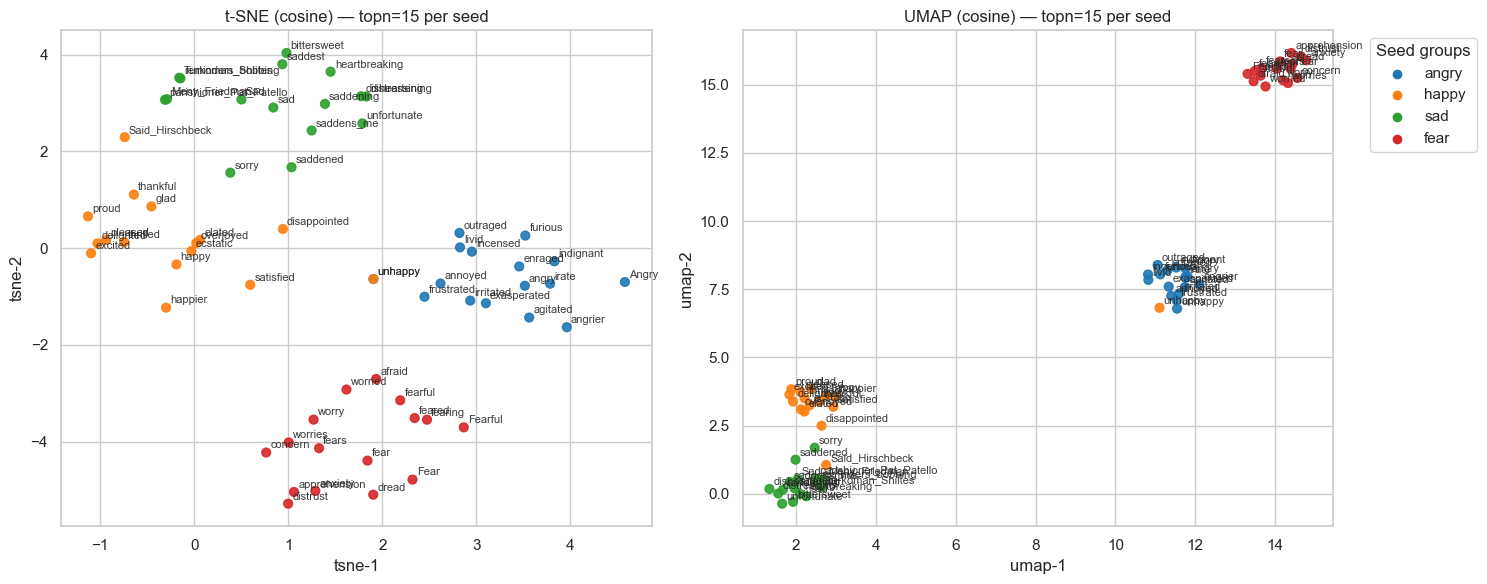

In [414]:
# t-SNE and UMAP for 15 neighbors per seed

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE

# prefer the commonly used KeyedVectors names if present
if 'w2v_google_model' in globals():
    model = w2v_google_model
elif 'glove_twitter_25_model' in globals():
    model = glove_twitter_25_model
elif 'word2vec_model' in globals():
    # word2vec_model from gensim Word2Vec (has .wv)
    model = word2vec_model.wv if hasattr(word2vec_model, 'wv') else word2vec_model
else:
    raise RuntimeError("No pretrained gensim model found in globals. Load 'w2v_google_model', 'glove_twitter_25_model', or 'word2vec_model' first.")

# helper to test membership and fetch vectors (works for KeyedVectors or Word2Vec.wv)
def in_vocab(m, w):
    try:
        return w in m.key_to_index
    except Exception:
        try:
            return w in m.vocab  # older gensim
        except Exception:
            return False

def get_vec(m, w):
    try:
        return m[w]
    except Exception:
        return m.wv[w]

# seeds and neighbor count
seeds = ['angry', 'happy', 'sad', 'fear']   # order used for grouping/colors
topn = 15

# collect neighbors (keep seed first so it's easier to spot)
groups = []
for s in seeds:
    group = [s]
    try:
        # model.most_similar returns words known to the model
        neighbours = [w for w, _ in model.most_similar(s, topn=topn)]
        group.extend(neighbours)
    except Exception as e:
        # if the seed is not in vocab or other issue, try to continue gracefully
        print(f"Warning: could not get neighbours for seed '{s}': {e}")
    groups.append(group)

# flatten into list preserving group order (duplicates allowed)
target_words = []
group_idx = []  # parallel list of group indices for color mapping
for i, g in enumerate(groups):
    for w in g:
        # skip words not in vocab (shouldn't happen for most_similar outputs, but check defensively)
        if in_vocab(model, w):
            target_words.append(w)
            group_idx.append(i)
        else:
            print(f"Skipping OOV word: {w}")

print(f"Collected {len(target_words)} words ({sum(len(g) for g in groups)} before OOV filtering).")

# get vectors
X = np.vstack([get_vec(model, w) for w in target_words])

# t-SNE embedding
tsne = TSNE(n_components=2, metric='cosine', perplexity=30, random_state=28, init='pca')
X_tsne = tsne.fit_transform(X)

# UMAP embedding
try:
    import umap.umap_ as umap
except Exception:
    import umap as umap  # some installs expose umap
umap_model = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15, min_dist=0.1, random_state=28)
X_umap = umap_model.fit_transform(X)

# plotting
palette = sns.color_palette("tab10", n_colors=len(seeds))
colors = [palette[i] for i in group_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax_tsne, ax_umap = axes

# TSNE plot
ax_tsne.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, s=40, alpha=0.9)
for i, w in enumerate(target_words):
    ax_tsne.annotate(w, (X_tsne[i, 0], X_tsne[i, 1]), fontsize=8, alpha=0.9, xytext=(3,3), textcoords='offset points')
ax_tsne.set_title("t-SNE (cosine) — topn=15 per seed")
ax_tsne.set_xlabel("tsne-1")
ax_tsne.set_ylabel("tsne-2")

# UMAP plot
ax_umap.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, s=40, alpha=0.9)
for i, w in enumerate(target_words):
    ax_umap.annotate(w, (X_umap[i, 0], X_umap[i, 1]), fontsize=8, alpha=0.9, xytext=(3,3), textcoords='offset points')
ax_umap.set_title("UMAP (cosine) — topn=15 per seed")
ax_umap.set_xlabel("umap-1")
ax_umap.set_ylabel("umap-2")

# add a legend (one marker per seed)
for i, seed in enumerate(seeds):
    axes[1].scatter([], [], c=[palette[i]], label=seed)
axes[1].legend(title="Seed groups", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

---